In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

nutri_vars = [
    "energy_100g", "sugars_100g", "saturated-fat_100g", "fat_100g",
    "sodium_100g", "fruits-vegetables-nuts-estimate-from-ingredients_100g",
    "fiber_100g", "proteins_100g",
]

data_path = "/kaggle/input/datasets/mamadoundiagne/open-food-facts-cleaned/df_cleaned.csv"

In [2]:
df = pd.read_csv(
    data_path, sep="\t",
    usecols=["code", "pnns_groups_1", "pnns_groups_2", "nutriscore_grade"] + nutri_vars,
    low_memory=False,
)

p1 = df["pnns_groups_1"].fillna("").str.lower().str.strip()
p2 = df["pnns_groups_2"].fillna("").str.lower().str.strip()

df["category"] = np.select(
    [
        p2 == "waters and flavored waters",
        p1.isin({"beverages", "alcoholic beverages"}) | p2.isin({
            "sweetened beverages", "unsweetened beverages",
            "artificially sweetened beverages", "fruit juices",
            "fruit nectars", "teas and herbal teas and coffees"}),
        p2 == "cheese",
        p1.isin({"fat and sauces"}) | p2.isin({"fats", "dressings and sauces"}),
    ],
    ["water", "beverage", "cheese", "fat"],
    default="solid",
)

In [3]:
def tsv(s, th, base=0):
    sc = np.full(len(s), base + len(th), dtype=float)
    for i in range(len(th) - 1, -1, -1):
        sc = np.where(s <= th[i], base + i, sc)
    return pd.Series(sc, index=s.index)

def score_energy(e, bev):
    b = np.where(e == 0, 0, tsv(e, [30,60,90,120,150,180,210,240,270], 1))
    return pd.Series(np.where(bev, b, tsv(e, [335,670,1005,1340,1675,2010,2345,2680,3015,3350])), index=e.index)

def score_sugar(s, bev):
    b = np.where(s == 0, 0, tsv(s, [1.5,3,4.5,6,7.5,9,10.5,12,13.5], 1))
    return pd.Series(np.where(bev, b, tsv(s, [4.5,9,13.5,18,22.5,27,31,36,40,45])), index=s.index)

def score_satfat(g):
    return tsv(g, [1,2,3,4,5,6,7,8,9,10])

def score_satfat_ratio(ratio):
    sc = np.zeros(len(ratio), dtype=float)
    for i, t in enumerate([10,16,22,28,34,40,46,52,58,64]):
        sc = np.where(ratio >= t, i + 1, sc)
    return pd.Series(sc, index=ratio.index)

def score_sodium(so):
    return tsv(so * 1000, [90,180,270,360,450,540,630,720,810,900])

def score_fruits(f, bev):
    b = pd.Series(np.select([f<=40, f<=60, f<=80], [0,2,4], default=10), index=f.index)
    s = pd.Series(np.select([f<=40, f<=60, f<=80], [0,1,2], default=5),  index=f.index)
    return pd.Series(np.where(bev, b, s), index=f.index)

def score_fiber(phi):
    return tsv(phi, [0.9, 1.9, 2.8, 3.7, 4.7])

def score_protein(pr):
    return tsv(pr, [1.6, 3.2, 4.8, 6.4, 8.0])

def compute_nutriscore(df):
    v = {c: pd.to_numeric(df[c], errors="coerce").fillna(0) for c in nutri_vars}
    bev = (df["category"] == "beverage").values
    fat = (df["category"] == "fat").values
    idx = df.index

    e, su, g, ft, so = (v["energy_100g"], v["sugars_100g"], v["saturated-fat_100g"],
                        v["fat_100g"], v["sodium_100g"])
    f, phi, pr = (v["fruits-vegetables-nuts-estimate-from-ingredients_100g"],
                  v["fiber_100g"], v["proteins_100g"])

    ratio = (g / ft.replace(0, np.nan) * 100).fillna(0)
    f_ = pd.Series(False, index=idx)
    b_ = pd.Series(bev, index=idx)

    pa_fat = score_energy(e, f_) + score_satfat_ratio(ratio) + score_sugar(su, f_) + score_sodium(so)
    pa_oth = score_energy(e, b_) + score_satfat(g)           + score_sugar(su, b_) + score_sodium(so)
    pa     = pd.Series(np.where(fat, pa_fat, pa_oth), index=idx)

    fln = score_fruits(f, b_)
    fib = score_fiber(phi)
    pro = score_protein(pr)
    mx  = np.where(bev, 10, 5)
    ok  = (pa < 11) | (fln.values == mx)

    return pd.Series(np.where(ok, pa - (fln + fib + pro), pa - fln - fib), index=idx)

def compute_grade(score, cat):
    bev = cat == "beverage"
    wat = cat == "water"
    bg = np.select([score<=1, score<=5,  score<=9],  ["b","c","d"], default="e")
    sg = np.select([score<=-1, score<=2, score<=10, score<=18], ["a","b","c","d"], default="e")
    g  = np.where(bev, bg, sg)
    return pd.Series(np.where(wat, "a", g), index=score.index)

In [4]:
rng = np.random.default_rng(42)

# 50k lignes complètes tirées au hasard
df_complete = df.dropna(subset=nutri_vars).copy()
df_sample = df_complete.sample(n=50_000, random_state=42).copy()

# grade de référence calculé sur les données complètes
df_sample["score_ref"] = compute_nutriscore(df_sample)
df_sample["grade_ref"] = compute_grade(df_sample["score_ref"], df_sample["category"])

# masquage 25%
x = df_sample[nutri_vars].values.copy()
mask = rng.random(x.shape) < 0.25
x_masked = x.copy()
x_masked[mask] = np.nan

print(f"valeurs masquées : {mask.sum():,} / {mask.size:,}  ({mask.mean():.1%})")

# entraînement des imputeurs sur le même sample (sans fuite : on fit sur les données masquées)
imp_mean = SimpleImputer(strategy="mean").fit(x_masked)
imp_med  = SimpleImputer(strategy="median").fit(x_masked)
imp_knn  = KNNImputer(n_neighbors=5).fit(x_masked)
imp_mf   = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    random_state=42,
).fit(x_masked)

imputeurs = {"mean": imp_mean, "median": imp_med, "knn": imp_knn, "missforest": imp_mf}

valeurs masquées : 100,270 / 400,000  (25.1%)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [5]:
rows = []
for name, imp in imputeurs.items():
    x_imp = imp.transform(x_masked)
    rmse  = np.sqrt(np.mean((x_imp[mask] - x[mask]) ** 2))
    mae   = np.mean(np.abs(x_imp[mask] - x[mask]))
    rows.append({"imputeur": name, "rmse": rmse, "mae": mae})

pd.DataFrame(rows).set_index("imputeur").sort_values("rmse").round(4)

,rmse,mae
imputeur,,
missforest,137.2445,32.5907
knn,259.2668,81.5659
mean,270.4877,89.8199
median,271.0182,88.7392


In [6]:
results = {}

for name, imp in imputeurs.items():
    x_imp = imp.transform(x_masked)
    df_tmp = df_sample.copy()
    df_tmp[nutri_vars] = x_imp
    df_tmp["score_imp"] = compute_nutriscore(df_tmp)
    df_tmp["grade_imp"] = compute_grade(df_tmp["score_imp"], df_tmp["category"])
    results[name] = df_tmp["grade_imp"].values

grades = ["a", "b", "c", "d", "e"]
y_ref  = df_sample["grade_ref"].values

print("accuracy - grade imputé vs grade calculé (référence)")
for name, preds in results.items():
    acc = accuracy_score(y_ref, preds)
    print(f"  {name:<12} {acc:.4f}")

accuracy - grade imputé vs grade calculé (référence)
  mean         0.6103
  median       0.6415
  knn          0.6208
  missforest   0.7896


In [7]:
valid = df_sample["nutriscore_grade"].str.lower().isin(grades)
y_off = df_sample.loc[valid, "nutriscore_grade"].str.lower().values

print("accuracy - grade imputé vs grade original open food facts")
for name, preds in results.items():
    acc = accuracy_score(y_off, np.array(preds)[valid])
    print(f"  {name:<12} {acc:.4f}")

accuracy - grade imputé vs grade original open food facts
  mean         0.4752
  median       0.4587
  knn          0.4715
  missforest   0.5331


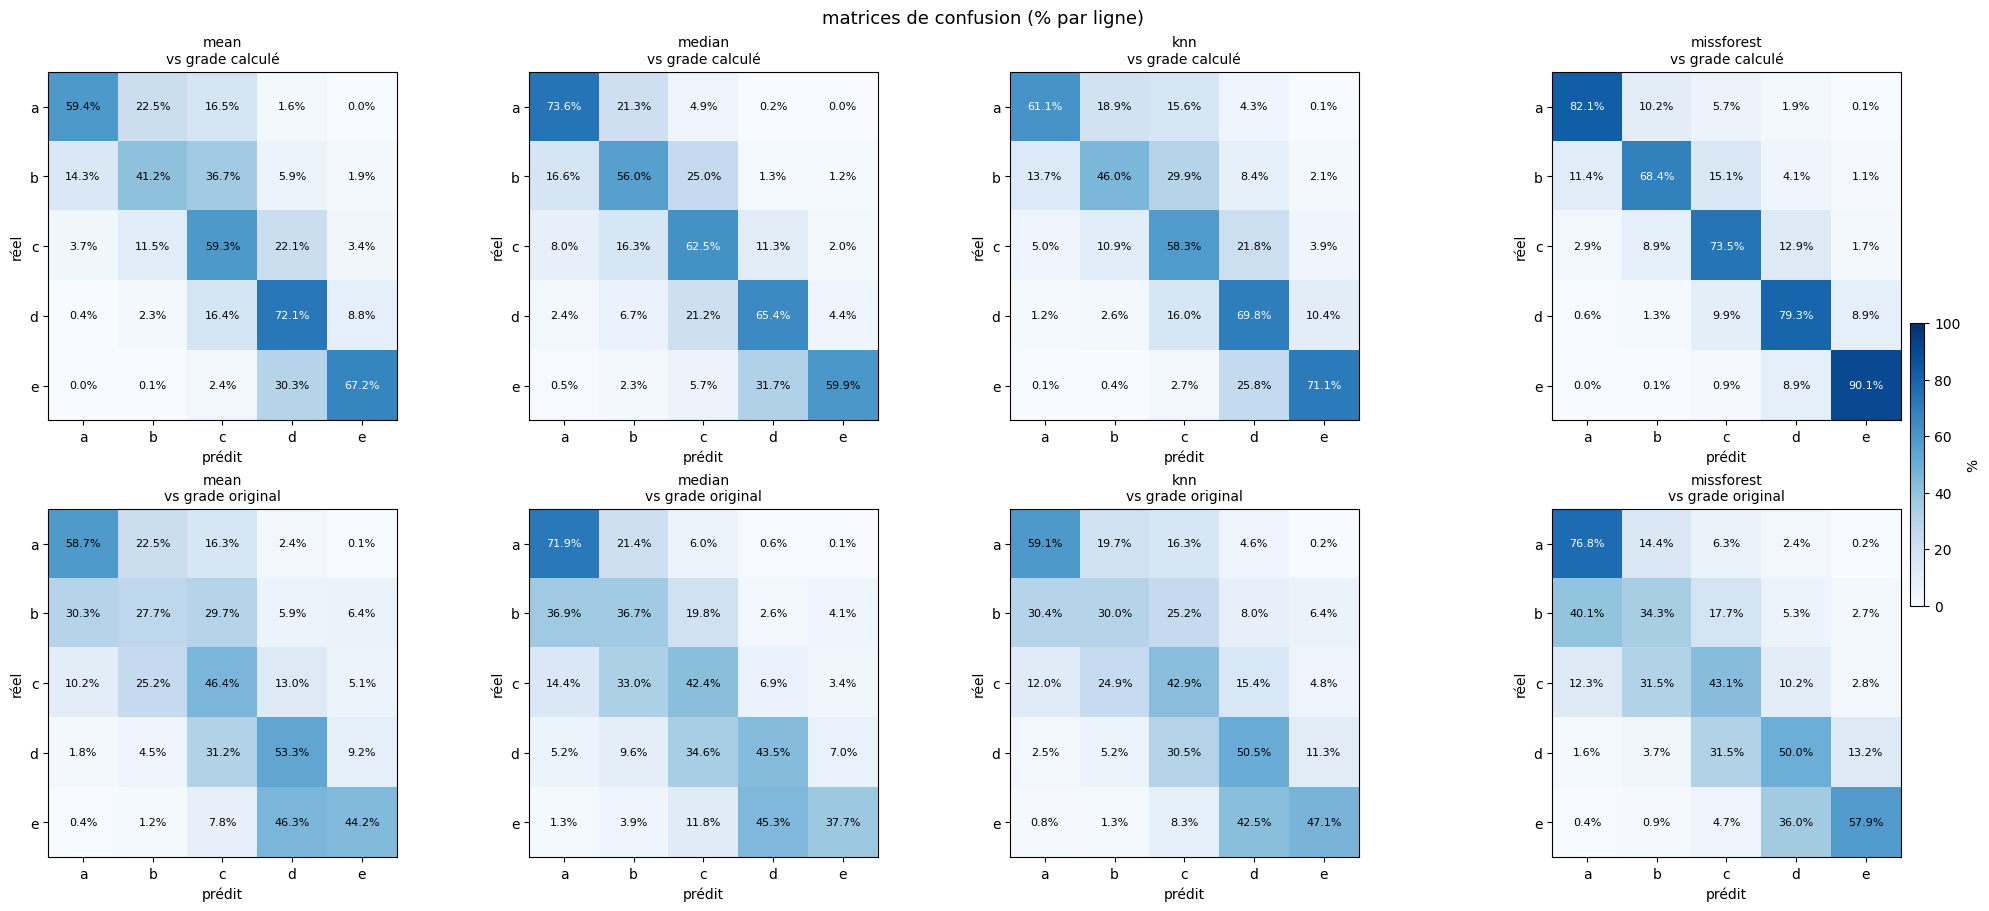

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), constrained_layout=True)

for col, (name, preds) in enumerate(results.items()):
    for row, (y_true, y_pred_arr, label) in enumerate([
        (y_ref,  np.array(preds),        "vs grade calculé"),
        (y_off,  np.array(preds)[valid], "vs grade original"),
    ]):
        cm = confusion_matrix(y_true, y_pred_arr, labels=grades)
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        ax = axes[row, col]
        im = ax.imshow(cm_pct, vmin=0, vmax=100, cmap="Blues")

        for i in range(len(grades)):
            for j in range(len(grades)):
                val = cm_pct[i, j]
                color = "white" if val > 60 else "black"
                ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                        fontsize=8, color=color)

        ax.set_xticks(range(len(grades)))
        ax.set_yticks(range(len(grades)))
        ax.set_xticklabels(grades)
        ax.set_yticklabels(grades)
        ax.set_xlabel("prédit")
        ax.set_ylabel("réel")
        ax.set_title(f"{name}\n{label}", fontsize=10)

fig.colorbar(im, ax=axes[:, -1], fraction=0.03, pad=0.02, label="%")
fig.suptitle("matrices de confusion (% par ligne)", fontsize=13)
plt.show()